In [1]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt 
from scipy.stats import t
from scipy.stats import binom
from scipy.stats import hypergeom
from scipy.stats import norm
from scipy.stats import skew
from scipy.stats import kurtosis
import pingouin as pg ## für t-Test

import warnings
warnings.filterwarnings("ignore")

**Hinweise:** 

- Hypergeometrische Verteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.htmlwelche 
(ACHTUNG: Die verwendeten Variablen in der Python Funktion unterscheiden sich von den Variablen, welche wir in der VO definiert haben.)
- Binomialverteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
- Normalverteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm
- t-Verteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
- $\chi^2$-Verteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html?highlight=chi2
- t-Test: https://pingouin-stats.org/generated/pingouin.ttest.html

- Schiefe: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html 
- Wölbung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html


# Blatt 2: Wahrscheinlichkeiten, Verteilungen und Schließende Statistik

## 1) Wahrscheinlichkeiten und Erwartungswert

Eine Tombola hat 100 Lose, jedes Los kostet 2 €. Es gibt folgende Gewinne: 
- 1 Hauptpreis: 50 €
- 4 Trostpreise: je 10 €
- der Rest: kein Gewinn

Bestimme den zu erwartenden Gewinn. Würdest du das Spiel spielen?

In [4]:
#Lose_Wahrscheinlichkeiten
Hauptpreis = 1/100
Trostpreis = 4/100
Rest = 95/100

#Nettwogewinn
Gewinn_Haupt = 48
Gewinn_Trost = 8
Gewinn_Rest = -2

#Erwartungswert
Erwartungswert = (Hauptpreis*Gewinn_Haupt)+(Trostpreis*Gewinn_Trost)+(Rest*Gewinn_Rest)
print(f"Erwartungswert: {Erwartungswert:.2f}€")

Erwartungswert: -1.10€


Da der zu Erwartende Gewinn pro Lost -1.10€ ist es nicht ratsam zu spielen.

## 2) Hähnchen oder doch Ratte? 

Ein Restaurant verkauft große Mengen an frittierten Hähnchenteilen. Aufgrund mangelnder
Hygiene bestehen die vermeintlichen Hähnchenteile mit einer Wahrscheinlichkeit von 2% aus
Ratte. Besteht ein verkauftes Teil aus Ratte, so fällt dieses zu 70% durch unangenehmen
Geschmack auf. Bei Hähnchen ist dies nur zu 5% der Fall.

a) Beim Essen fällt dir ein unangenehmer Geruch auf. Mit welcher Wahrscheinlichkeit befindet sich ein Rattenteilchen auf deinem Teller? **Interpretiere das Ergebnis.** 

b) Beim Essen fällt dir ein unangenehmer Geruch auf. Mit welcher Wahrscheinlichkeit befindet sich nur Hähnchen auf deinem Teller? **Interpretiere das Ergebnis.** 

In [6]:
isRat = 2/100
isChicken = 98/100

isTastyRat = 30/100
isNotTastyRat = 70/100

isTastyChicken = 95/100
isNotTastyChicken = 5/100

#a) Unangenehmer Geruch mit welcher Wahrscheinlichkeit ist ratte?
P_Unpleasant = isRat*isNotTastyRat + isChicken*isNotTastyChicken
P_Unpleasant_Rat = isRat * isNotTastyRat

P_unpleasant_is_Rat = P_Unpleasant_Rat / P_Unpleasant
print(f"Wahrscheinlichkeit, dass bei unangenehmem Geruch eine Ratte vorliegt: {P_unpleasant_is_Rat:.2%}")

#b) Unangenehmer Geruch mit welcher Wahrscheinlichkeit ist Huhn?
P_Unpleasant_Chicken = isChicken * isNotTastyChicken
P_unpleasant_is_Chicken = P_Unpleasant_Chicken / P_Unpleasant
print(f"Wahrscheinlichkeit, dass bei unangenehmem Geruch ein Huhn vorliegt: {P_unpleasant_is_Chicken:.2%}")


Wahrscheinlichkeit, dass bei unangenehmem Geruch eine Ratte vorliegt: 22.22%
Wahrscheinlichkeit, dass bei unangenehmem Geruch ein Huhn vorliegt: 77.78%


Die Wahrscheinlichkeit, dass der unangenehme Geruch tatsächlich von einer Ratte stammt, ist deutlich geringer, als die Wahrscheinlichkeit, dass er von einem Hähnchen stammt. Dies liegt daran, dass die allgemeine Wahrscheinlichkeit (die Basisrate), ein Hähnchenteil zu erhalten, weitaus höher ist als die, ein Rattenteil zu erhalten.

## 3) Qualitätskontrolle #1
Eine Lieferung von 27 Stiften enthält 2 Stifte, die defekt sind. Der Empfänger testet zur Kontrolle 3 Stifte und behält die Lieferung, falls alle 3 funktionieren. 

a) Welche Verteilung liegt zugrunde. Warum? Visualiere pdf und cdf 

b) Wie groß ist die Wahrscheinlichkeit, dass 1 Stift defekt ist? 

c) Wie groß ist die Wahrscheinlichkeit, dass mindestens 1 Stift defekt ist? 

d) Wie groß ist die Wahrscheinlichkeit, dass der Empfänger die Lieferung behält? 

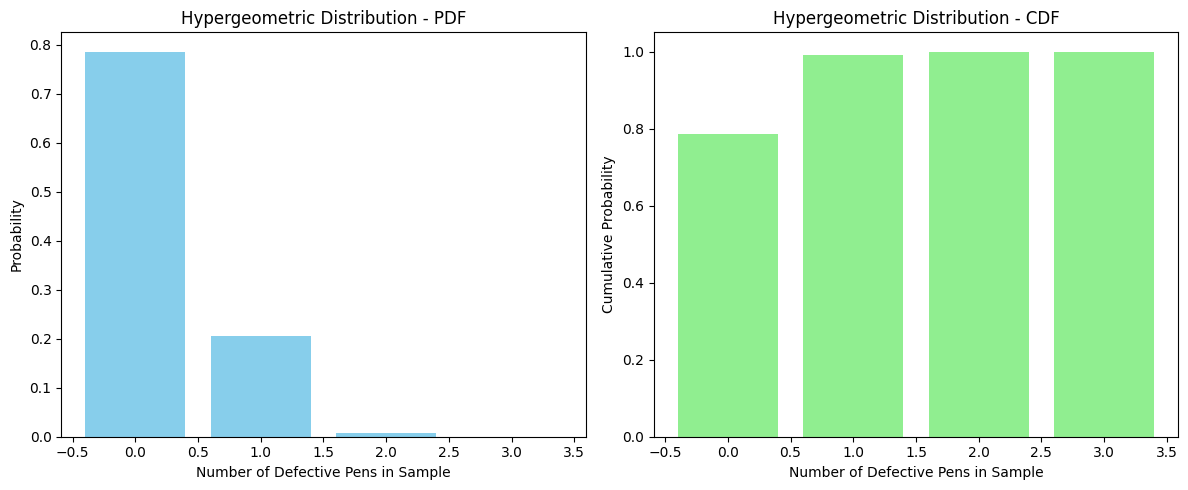

Wahrscheinlichkeit genau 1 defekter Stift in der Stichprobe: 20.51%
Wahrscheinlichkeit mindestens 1 defekter Stift in der Stichprobe: 21.37%
Wahrscheinlichkeit, dass der Empfänger die Lieferung behält: 78.63%


In [11]:
amountPen = 27
defectivePen = 2

amountOfControl = 3

#a) Verteilung pdf cdf als plots
x = np.arange(0, amountOfControl+1)
pdf = hypergeom.pmf(x, amountPen, defectivePen, amountOfControl)
cdf = hypergeom.cdf(x, amountPen, defectivePen, amountOfControl)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(x, pdf, color='skyblue')
plt.title('Hypergeometric Distribution - PDF')
plt.xlabel('Number of Defective Pens in Sample')
plt.ylabel('Probability')
plt.subplot(1, 2, 2)
plt.bar(x, cdf, color='lightgreen')
plt.title('Hypergeometric Distribution - CDF')
plt.xlabel('Number of Defective Pens in Sample')
plt.ylabel('Cumulative Probability')
plt.tight_layout()
plt.show()


#b) Wahrscheinlichkeit 1 defekter Stift
P_1_defective = hypergeom.pmf(1, amountPen, defectivePen, amountOfControl)
print(f"Wahrscheinlichkeit genau 1 defekter Stift in der Stichprobe: {P_1_defective:.2%}")

#c) wahrscheinlichkeit mindestens 1 defekter Stift
P_at_least_1_defective = 1 - hypergeom.pmf(0, amountPen, defectivePen, amountOfControl)
print(f"Wahrscheinlichkeit mindestens 1 defekter Stift in der Stichprobe: {P_at_least_1_defective:.2%}")

#d) Wahrscheinlichkeit dass Empfänger Lieferung behält (kein defekter Stift in Stichprobe)
P_no_defective = hypergeom.pmf(0, amountPen, defectivePen, amountOfControl)
print(f"Wahrscheinlichkeit, dass der Empfänger die Lieferung behält: {P_no_defective:.2%}")



## 4) Qualitätskontrolle #2

In einer Produktion ist der Anteil fehlerhafter Bauteile gleichbleibend $4\%$. $X = $ Anzahl an fehlerhaften Bauteilen. 

a) Welche Verteilung liegt zugrund? Warum? Visualisiere pdf und cdf. 

b) Wie groß ist die Wahrscheinlichkeit, dass in einer zufälligen Stichprobe von 500 Einheiten mindestens zwei und maximal fünf fehlerhafte Einheiten gefunden werden? 

c) Wieviele fehlerhafte Bauteile sind zu erwarten?

d) Wie groß muss die Stichprobe gewählt werden, um mit mindestens 90%iger Sicherheit
mindestens eine fehlerhafte Einheit zu entdecken?

e) Verwende bei der Aufgabenstellung b) zusätzlich die Approximation durch die Normalverteilung, falls erlaubt. Vergleiche die Ergebnisse 

## a) Verteilung und Visualisierung
Die Binomialverteilung liegt vor, da es sich um eine Serie von unabhängigen Bernoulli-Experimenten handelt,
bei denen jedes Bauteil entweder defekt oder nicht defekt ist.


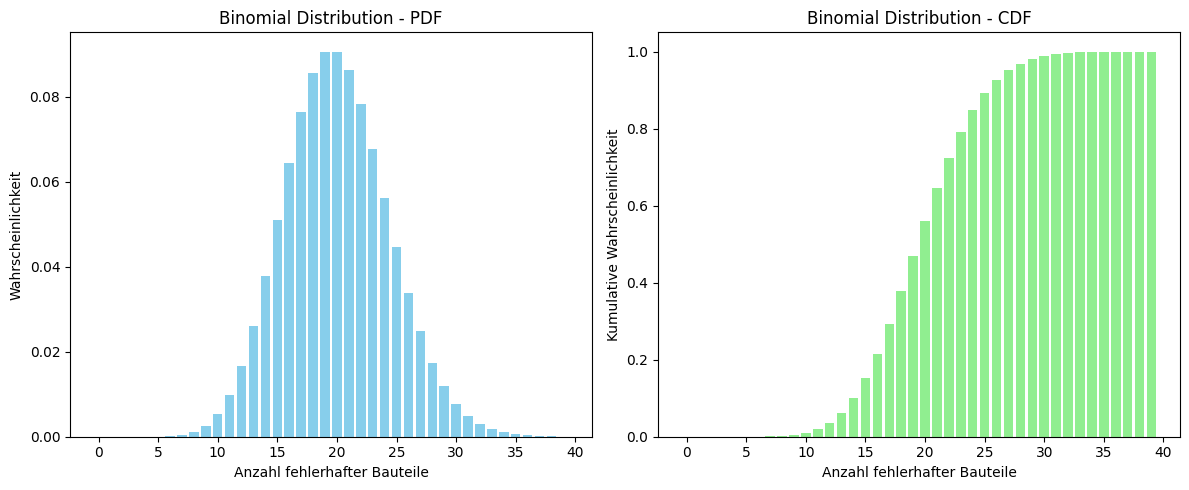


## b) Exakte Wahrscheinlichkeit P(2 <= X <= 5)
P(X=2) + P(X=3) + P(X=4) + P(X=5): 0.000057
Wahrscheinlichkeit (Exakt): 0.01%

## c) Erwarteter Wert E(X)
Erwartete Anzahl defekter Bauteile in der Stichprobe (E(X) = n * p): 20.0

## d) Erforderliche Stichprobengröße (n)
n (minimal, analytisch): 56.41
Erforderliche Stichprobengröße (aufgerundet): 57

## e) Normalapproximation
Mittelwert (μ): 20.0, Standardabweichung (σ): 4.382
z_unten (1.5): -4.222, z_oben (5.5): -3.309
Wahrscheinlichkeit (Normalapproximation): 0.000456 (0.05%)

Vergleich:
Exakter Wert: 0.000057
Approximierter Wert: 0.000456
Absoluter Unterschied: 0.000399
Die Normalapproximation überschätzt den exakten Wert deutlich. Der Grund ist, dass das betrachtete Intervall (2 bis 5) extrem weit
vom Erwartungswert (μ = 20) entfernt liegt. In den Randbereichen
liefert die Normalverteilung trotz Stetigkeitskorrektur eine
schlechte Approximation der Binomialverteilung.


In [19]:
import numpy as np
from scipy.stats import binom, norm
import matplotlib.pyplot as plt

# --- Gegebene Werte ---
fehlerhafteBauteileProzent = 4/100  # p = 0.04
anzahlBauteile = 500             # n = 500

# --- a) Verteilung und Visualisierung ---
print("## a) Verteilung und Visualisierung")
print("Die Binomialverteilung liegt vor, da es sich um eine Serie von unabhängigen Bernoulli-Experimenten handelt,")
print("bei denen jedes Bauteil entweder defekt oder nicht defekt ist.")

x = np.arange(0, 40)
pdf = binom.pmf(x, anzahlBauteile, fehlerhafteBauteileProzent)
cdf = binom.cdf(x, anzahlBauteile, fehlerhafteBauteileProzent)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(x, pdf, color='skyblue')
plt.title('Binomial Distribution - PDF')
plt.xlabel('Anzahl fehlerhafter Bauteile')
plt.ylabel('Wahrscheinlichkeit')
plt.subplot(1, 2, 2)
plt.bar(x, cdf, color='lightgreen')
plt.title('Binomial Distribution - CDF')
plt.xlabel('Anzahl fehlerhafter Bauteile')
plt.ylabel('Kumulative Wahrscheinlichkeit')
plt.tight_layout()
plt.show()


# --- b) Exakte Wahrscheinlichkeit P(2 <= X <= 5) ---
print("\n## b) Exakte Wahrscheinlichkeit P(2 <= X <= 5)")
P_2_defective = binom.pmf(2, anzahlBauteile, fehlerhafteBauteileProzent)
P_3_defective = binom.pmf(3, anzahlBauteile, fehlerhafteBauteileProzent)
P_4_defective = binom.pmf(4, anzahlBauteile, fehlerhafteBauteileProzent)
P_5_defective = binom.pmf(5, anzahlBauteile, fehlerhafteBauteileProzent)

P_between_2_and_5_defective = P_2_defective + P_3_defective + P_4_defective + P_5_defective

# Ausgabe mit höherer Präzision, um den Fehler der vorherigen Runde zu vermeiden
print(f"P(X=2) + P(X=3) + P(X=4) + P(X=5): {P_between_2_and_5_defective:.6f}")
print(f"Wahrscheinlichkeit (Exakt): {P_between_2_and_5_defective:.2%}")

# --- c) Erwarteter Wert ---
print("\n## c) Erwarteter Wert E(X)")
expected_defective = anzahlBauteile * fehlerhafteBauteileProzent
print(f"Erwartete Anzahl defekter Bauteile in der Stichprobe (E(X) = n * p): {expected_defective:.1f}")

# --- d) Stichprobengröße für P(X >= 1) >= 0.90 ---
print("\n## d) Erforderliche Stichprobengröße (n)")
desired_probability = 0.90
# n = ln(1 - P(X>=1)) / ln(1 - p)
n = np.log(1 - desired_probability) / np.log(1 - fehlerhafteBauteileProzent)
print(f"n (minimal, analytisch): {n:.2f}")
print(f"Erforderliche Stichprobengröße (aufgerundet): {int(np.ceil(n))}")

# --- e) Normalapproximation und Vergleich ---
print("\n## e) Normalapproximation")
mean = anzahlBauteile * fehlerhafteBauteileProzent
std_dev = np.sqrt(anzahlBauteile * fehlerhafteBauteileProzent * (1 - fehlerhafteBauteileProzent))

# Stetigkeitskorrektur: P(2 <= X <= 5) wird P(1.5 <= X <= 5.5)
z_lower = (2 - 0.5 - mean) / std_dev
z_upper = (5 + 0.5 - mean) / std_dev

P_between_2_and_5_defective_norm = norm.cdf(z_upper) - norm.cdf(z_lower)
print(f"Mittelwert (μ): {mean:.1f}, Standardabweichung (σ): {std_dev:.3f}")
print(f"z_unten (1.5): {z_lower:.3f}, z_oben (5.5): {z_upper:.3f}")
print(f"Wahrscheinlichkeit (Normalapproximation): {P_between_2_and_5_defective_norm:.6f} ({P_between_2_and_5_defective_norm:.2%})")

# Vergleich
difference = abs(P_between_2_and_5_defective - P_between_2_and_5_defective_norm)
print(f"\nVergleich:")
print(f"Exakter Wert: {P_between_2_and_5_defective:.6f}")
print(f"Approximierter Wert: {P_between_2_and_5_defective_norm:.6f}")
print(f"Absoluter Unterschied: {difference:.6f}")
print("Die Normalapproximation überschätzt den exakten Wert deutlich. Der Grund ist, dass das betrachtete Intervall (2 bis 5) extrem weit")
print("vom Erwartungswert (μ = 20) entfernt liegt. In den Randbereichen")
print("liefert die Normalverteilung trotz Stetigkeitskorrektur eine")
print("schlechte Approximation der Binomialverteilung.")

## 5) Normalverteilung

a) Lade den Datensatz Pinguine und visualisiere die Flügel Länge von Adelie. Verwende einen density plot. 

b) Verwende die Schiefe und Wölbung um zu zeigen, dass die Flügel Länge dieser Spezie sehr wahrscheinlich normalverteilt ist. 

c) Wie groß ist die Wahrscheinlichkeit einen Pinguin Adelie zu treffen, dessen Flügel Länge größer als $200$ mm ist? 

d) Welche Flügellänge wird von $90\%$ der Adelie Pinguine überschritten? 

,Unnamed: 0,Individual ID,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,0,N1A1,Adelie,Torgersen,2007-11-11,39.1,18.7,181,3750,MALE
1,1,N1A2,Adelie,Torgersen,2007-11-11,39.5,17.4,186,3800,FEMALE
2,2,N2A1,Adelie,Torgersen,2007-11-16,40.3,18.0,195,3250,FEMALE
3,4,N3A1,Adelie,Torgersen,2007-11-16,36.7,19.3,193,3450,FEMALE
4,5,N3A2,Adelie,Torgersen,2007-11-16,39.3,20.6,190,3650,MALE


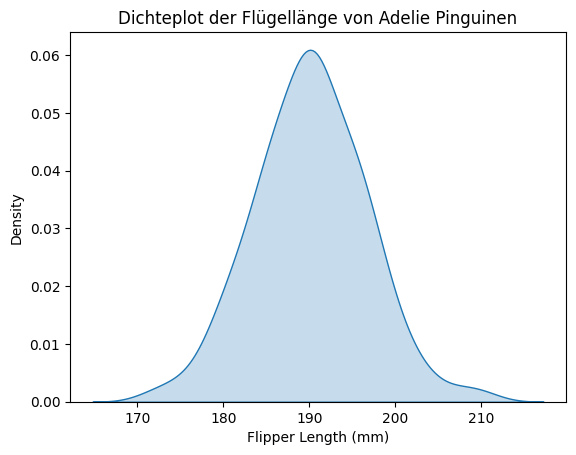

Schiefe: 0.0796
Wölbung (Kurtosis): 0.3277
Die Schiefe liegt nahe bei 0, was auf eine symmetrische Verteilung hinweist.
Die Wölbung liegt nahe bei 0, was auf eine Normalverteilung hinweist.
Wahrscheinlichkeit, einen Adelie Pinguin mit Flügellänge > 200mm zu treffen: 6.46%
Flügellänge, die von 90% der Adelie Pinguine überschritten wird: 181.74 mm


In [32]:
pinguin = pd.read_excel("penguinsSmall.xlsx")
display(pinguin.head())

#a) Lade das Dataset "penguinsSmall.xlsx" und visualisiere die Flügel Länge von Adelie. Verwende density Plot.
sn.kdeplot(data=pinguin[pinguin['Species'] == 'Adelie'], x='Flipper Length (mm)', fill=True)
plt.title('Dichteplot der Flügellänge von Adelie Pinguinen')
plt.show()

#b) Verwende die Schiefe und Wölbung um zu zeign, dass die Flügel Länge dieser Spezie sehr wahrscheinlich normalverteilt ist.
flipper_lengths = pinguin[pinguin['Species'] == 'Adelie']['Flipper Length (mm)']
skewness = skew(flipper_lengths)
kurt = kurtosis(flipper_lengths, fisher=True)
print(f"Schiefe: {skewness:.4f}")
print(f"Wölbung (Kurtosis): {kurt:.4f}")
if abs(skewness) < 0.5:
    print("Die Schiefe liegt nahe bei 0, was auf eine symmetrische Verteilung hinweist.")
if abs(kurt) < 1:
    print("Die Wölbung liegt nahe bei 0, was auf eine Normalverteilung hinweist.")
else:
    print("Die Verteilung weicht von der Normalverteilung ab.")

#c) Wie groß ist die Wahrscheinlichkeit einen Pinguin Adelie zu treffen, dessen Flügel Länge größer als 200mm ist?
mean_flipper = flipper_lengths.mean()
std_flipper = flipper_lengths.std()
z_score_200mm = (200 - mean_flipper) / std_flipper
P_greater_200mm = 1 - norm.cdf(z_score_200mm)
print(f"Wahrscheinlichkeit, einen Adelie Pinguin mit Flügellänge > 200mm zu treffen: {P_greater_200mm:.2%}")

#e) welche Flügellänge wird von 90% der Adelie Pinguine Überschritten
z_90 = norm.ppf(0.10)  # 10% links, 90% rechts
flipper_length_90 = mean_flipper + z_90 * std_flipper
print(f"Flügellänge, die von 90% der Adelie Pinguine überschritten wird: {flipper_length_90:.2f} mm")


## 6) Konfidenzintervalle

Bestimme die Konfidenzintervalle für den Erwartungswert von Flipper Length (mm) der verschiedenen Pinguine zum Niveau $\alpha = 0.05$. 

In [ ]:
display(pinguin.head())

alpha = 0.05


,Unnamed: 0,Individual ID,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,0,N1A1,Adelie,Torgersen,2007-11-11,39.1,18.7,181,3750,MALE
1,1,N1A2,Adelie,Torgersen,2007-11-11,39.5,17.4,186,3800,FEMALE
2,2,N2A1,Adelie,Torgersen,2007-11-16,40.3,18.0,195,3250,FEMALE
3,4,N3A1,Adelie,Torgersen,2007-11-16,36.7,19.3,193,3450,FEMALE
4,5,N3A2,Adelie,Torgersen,2007-11-16,39.3,20.6,190,3650,MALE


## 7) Hypothesentests

Ein Tierarzt behauptet, dass der Erwartungswert der Flipper Length (mm) der unterschiedlichen Pinguine 190 misst. Überprüfe diese Aussage mittels Hypothesentest (Signifikanzniveau  𝛼=0.05 ). 